# Insert/Delete Toy Schedule Explorer (Production Modules)

This notebook is **toy-vocab only** for readability, but it uses the same core modules as training/inference integration:

- `models/insertdelete/custom_schedules.py`
- `models/insertdelete/bridge.py`
- `google_d3pm_ins_del/forward_process.py`
- `google_d3pm_ins_del/schedules.py`

Goals:
1. Build schedules through the same config-style path used in code.
2. Visualize per-step transition operators and insert/delete rates.
3. Animate matrix evolution as GIF.
4. Sample forward trajectories and animate sequence evolution + event statistics.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "models").exists() and (ROOT.parent / "models").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("ROOT:", ROOT)


ROOT: /Users/alfred/Documents/Code/denovo_base


In [2]:
import functools
from pathlib import Path

import numpy as np
import torch
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

from models.insertdelete.bridge import InsertDeleteTorchJaxBridge
from models.insertdelete import custom_schedules
from google_d3pm_ins_del import forward_process as gfp
from google_d3pm_ins_del import util as gutil


## 1) Toy Vocabulary + Bridge

We keep a tiny AA-like vocab so matrices are readable.


In [3]:
TOY_TOKENS = [
    "A", "G", "N", "Q",
    "X", "<MASK>", "<INS>", "<DEL>",
]
dictionary = {tok: i for i, tok in enumerate(TOY_TOKENS)}
MAX_LEN = 14

bridge = InsertDeleteTorchJaxBridge(
    dictionary,
    max_len=MAX_LEN,
    include_mask_in_vocab=True,
)
id_to_tok = {v: k for k, v in dictionary.items()}
jax_vocab_tokens = [id_to_tok[int(i)] for i in bridge.jax_to_torch]

print("dictionary:", dictionary)
print("jax modeled vocab order:", jax_vocab_tokens)
print("modeled vocab size:", bridge.real_vocab_size)
print("mask_token_jax:", bridge.mask_token_jax())


dictionary: {'A': 0, 'G': 1, 'N': 2, 'Q': 3, 'X': 4, '<MASK>': 5, '<INS>': 6, '<DEL>': 7}
jax modeled vocab order: ['A', 'G', 'N', 'Q', '<MASK>']
modeled vocab size: 5
mask_token_jax: 4


## 2) Schedule Presets (Google-like construction path)

These presets are all built via `custom_schedules.build_schedule_from_config`, which internally uses
Google-style `schedule_from_interpolators` logic.


In [4]:
T = 24

PRESETS = {
    # Near in-place corruption; very low edit refresh.
    "near_inplace_uniform": {
        "transition_type": "uniform",
        "insert_type": "uniform",
        "final_relative_size": 1.0,
        "final_refresh_prob": 0.0,
        "initial_slope": 1.0,
        "acceleration": 8.0,
        "deny_insert_tokens": ["X", "<MASK>", "<INS>", "<DEL>"],
    },
    # Small amount of insertion/deletion edits.
    "small_edits_uniform": {
        "transition_type": "uniform",
        "insert_type": "uniform",
        "final_relative_size": 1.0,
        "final_refresh_prob": 0.02,
        "initial_slope": 1.0,
        "acceleration": 8.0,
        "deny_insert_tokens": ["X", "<MASK>", "<INS>", "<DEL>"],
    },
    # Absorbing-mask transition variant (MDLM-like corruption + insert/delete machinery).
    "small_edits_absorbing_mask": {
        "transition_type": "mask",
        "insert_type": "mask",
        "final_relative_size": 1.0,
        "final_refresh_prob": 0.02,
        "initial_slope": 1.0,
        "acceleration": 8.0,
        # Keep MASK allowed here, since insert_type='mask' emits MASK.
        "deny_insert_tokens": ["X", "<INS>", "<DEL>"],
    },
    # More aggressive edits.
    "medium_edits_uniform": {
        "transition_type": "uniform",
        "insert_type": "uniform",
        "final_relative_size": 1.0,
        "final_refresh_prob": 0.08,
        "initial_slope": 1.0,
        "acceleration": 8.0,
        "deny_insert_tokens": ["X", "<MASK>", "<INS>", "<DEL>"],
    },
}


def build_schedule(preset_name: str):
    cfg = dict(PRESETS[preset_name])
    deny_insert_jax = bridge.resolve_deny_insert_jax(schedule_cfg=cfg, dictionary=dictionary)
    schedule = custom_schedules.build_schedule_from_config(
        num_steps=T,
        vocab_size=bridge.real_vocab_size,
        schedule_cfg=cfg,
        token_denylist=deny_insert_jax,
        mask_token=bridge.mask_token_jax(),
        max_len=MAX_LEN,
    )
    return schedule, cfg, deny_insert_jax


schedule_name = "small_edits_absorbing_mask"
schedule, schedule_cfg, deny_insert_jax = build_schedule(schedule_name)

print("schedule:", schedule_name)
print("num_steps (includes final all-delete step):", int(schedule.num_steps))
print("deny_insert_jax:", deny_insert_jax)
print("lp_insert[:5]:", np.asarray(schedule.steps.lp_insert[:5]))
print("lp_delete[:5]:", np.asarray(schedule.steps.lp_delete[:5]))


schedule: small_edits_absorbing_mask
num_steps (includes final all-delete step): 24
deny_insert_jax: ()
lp_insert[:5]: [-7.0483866 -7.0475173 -7.0466475 -7.0457764 -7.0449057]
lp_delete[:5]: [-7.0475173 -7.0466475 -7.045777  -7.0449047 -7.0440335]


## 3) Helpers: operator matrix extraction, plotting, GIF saving


In [5]:
def step_distn(schedule, t: int):
    return jax.tree.map(lambda x: x[t], schedule.steps)


def operator_to_matrix(A, vocab_size: int) -> np.ndarray:
    token_ids = jnp.arange(vocab_size, dtype=jnp.int32)
    log_rows = jax.vmap(functools.partial(A.apply, is_distn=False, log=True))(token_ids)
    return np.asarray(jnp.exp(log_rows), dtype=np.float64)


def _row_softmax(x: np.ndarray) -> np.ndarray:
    x = x - np.max(x, axis=-1, keepdims=True)
    e = np.exp(x)
    return e / np.clip(e.sum(axis=-1, keepdims=True), 1e-12, None)


def extract_schedule_arrays(schedule):
    n_steps = int(schedule.num_steps)
    mats = [operator_to_matrix(step_distn(schedule, t).A, bridge.real_vocab_size) for t in range(n_steps)]
    d_insert_logits = np.asarray(schedule.steps.D_insert_logits, dtype=np.float64)
    d_insert_probs = _row_softmax(d_insert_logits)
    lp_insert = np.asarray(schedule.steps.lp_insert)
    lp_delete = np.asarray(schedule.steps.lp_delete)
    p_insert = np.exp(lp_insert)
    p_delete = np.exp(lp_delete)
    weights = np.asarray(schedule.weights)
    return mats, d_insert_logits, d_insert_probs, lp_insert, lp_delete, p_insert, p_delete, weights


def save_gif(anim, path: Path, fps: int = 2):
    path.parent.mkdir(parents=True, exist_ok=True)
    anim.save(path, writer=PillowWriter(fps=fps))
    plt.close(anim._fig)
    return path


mats, d_insert_logits, d_insert_probs, lp_insert, lp_delete, p_insert, p_delete, weights = extract_schedule_arrays(schedule)
print("mats:", len(mats), mats[0].shape)
print("D_insert_logits:", d_insert_logits.shape)


mats: 24 (5, 5)
D_insert_logits: (24, 5)


## 4) Static quick-look


/var/folders/zr/fc3l9f6s3zq6t9rmwr2v0mhr0000gn/T/ipykernel_2775/3267033720.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


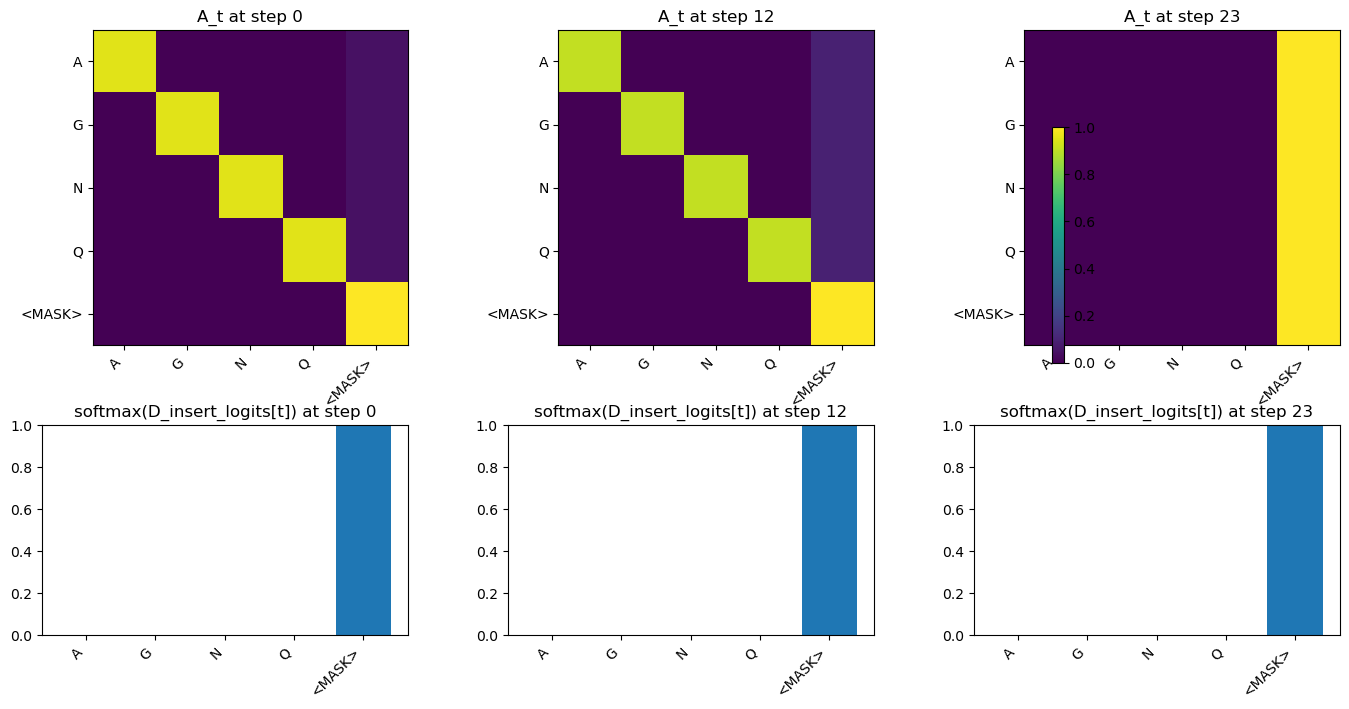

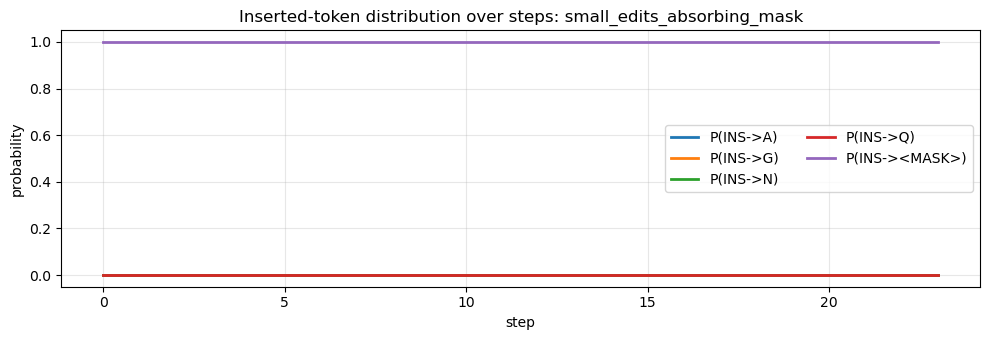

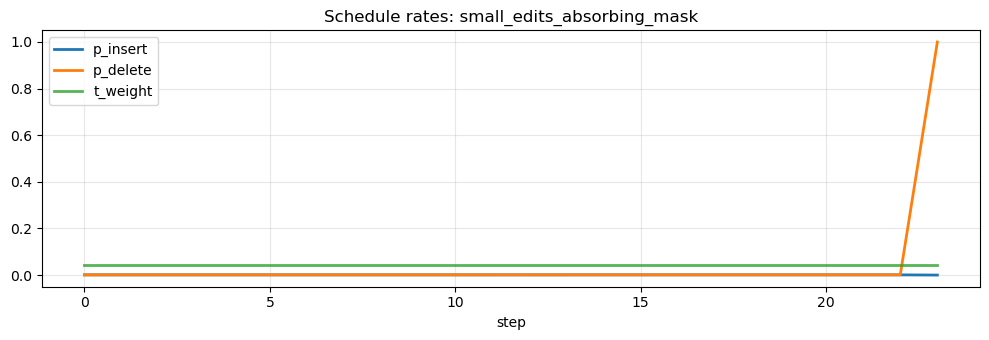

In [6]:
snapshot_steps = [0, int(len(mats)//2), len(mats)-1]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 2]})
for col, t in enumerate(snapshot_steps):
    im = axes[0, col].imshow(mats[t], vmin=0.0, vmax=1.0, cmap="viridis")
    axes[0, col].set_title(f"A_t at step {t}")
    axes[0, col].set_xticks(range(len(jax_vocab_tokens)))
    axes[0, col].set_yticks(range(len(jax_vocab_tokens)))
    axes[0, col].set_xticklabels(jax_vocab_tokens, rotation=45, ha="right")
    axes[0, col].set_yticklabels(jax_vocab_tokens)

    axes[1, col].bar(np.arange(len(jax_vocab_tokens)), d_insert_probs[t], color="tab:blue")
    axes[1, col].set_ylim(0.0, 1.0)
    axes[1, col].set_title(f"softmax(D_insert_logits[t]) at step {t}")
    axes[1, col].set_xticks(range(len(jax_vocab_tokens)))
    axes[1, col].set_xticklabels(jax_vocab_tokens, rotation=45, ha="right")

fig.colorbar(im, ax=axes[0, :].ravel().tolist(), shrink=0.8)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 3.5))
for k, tok in enumerate(jax_vocab_tokens):
    ax.plot(d_insert_probs[:, k], lw=2, label=f"P(INS->{tok})")
ax.set_title(f"Inserted-token distribution over steps: {schedule_name}")
ax.set_xlabel("step")
ax.set_ylabel("probability")
ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(p_insert, label="p_insert", lw=2)
ax.plot(p_delete, label="p_delete", lw=2)
ax.plot(weights, label="t_weight", lw=2, alpha=0.8)
ax.set_title(f"Schedule rates: {schedule_name}")
ax.set_xlabel("step")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()


## 5) GIF: Transition matrix evolution


saved: /Users/alfred/Documents/Code/denovo_base/notes/notebook_artifacts/small_edits_absorbing_mask_A_matrices.gif


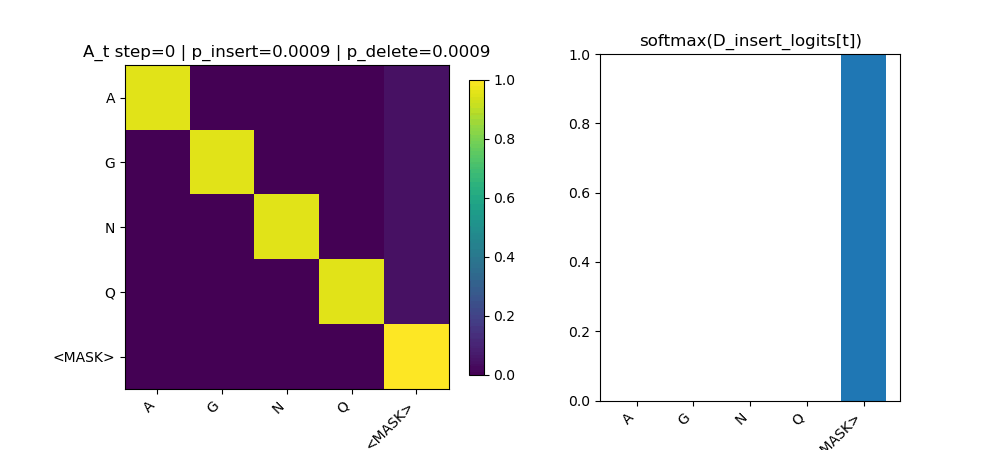

In [7]:
def make_matrix_gif(mats, d_insert_probs, p_insert, p_delete, labels, out_path: Path):
    n = len(mats)
    fig, (ax_mat, ax_ins) = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw={"width_ratios": [1.35, 1.0]})

    im = ax_mat.imshow(mats[0], vmin=0.0, vmax=1.0, cmap="viridis")
    ax_mat.set_xticks(range(len(labels)))
    ax_mat.set_yticks(range(len(labels)))
    ax_mat.set_xticklabels(labels, rotation=45, ha="right")
    ax_mat.set_yticklabels(labels)
    title = ax_mat.set_title("")
    fig.colorbar(im, ax=ax_mat, shrink=0.85)

    bars = ax_ins.bar(np.arange(len(labels)), d_insert_probs[0], color="tab:blue")
    ax_ins.set_ylim(0.0, 1.0)
    ax_ins.set_xticks(range(len(labels)))
    ax_ins.set_xticklabels(labels, rotation=45, ha="right")
    ax_ins.set_title("softmax(D_insert_logits[t])")

    def update(frame):
        im.set_data(mats[frame])
        title.set_text(
            f"A_t step={frame} | p_insert={p_insert[frame]:.4f} | p_delete={p_delete[frame]:.4f}"
        )
        vals = d_insert_probs[frame]
        for b, v in zip(bars, vals):
            b.set_height(float(v))
        return [im, title, *bars]

    anim = FuncAnimation(fig, update, frames=n, interval=600, blit=False)
    return save_gif(anim, out_path, fps=2)


gif_dir = ROOT / "notes" / "notebook_artifacts"
matrix_gif_path = gif_dir / f"{schedule_name}_A_matrices.gif"
_ = make_matrix_gif(mats, d_insert_probs, p_insert, p_delete, jax_vocab_tokens, matrix_gif_path)
print("saved:", matrix_gif_path)
display(Image(filename=str(matrix_gif_path)))


## 6) Forward trajectory sampling (toy sequences)

This uses `google_d3pm_ins_del.forward_process.sample_noise_step` with rejection sampling for validity.


In [8]:
jax_id_to_token = {i: tok for i, tok in enumerate(jax_vocab_tokens)}


def make_dynamic_sequence(tokens):
    torch_ids = [dictionary[t] for t in tokens]
    jax_ids = [int(bridge.torch_to_jax_lut[t]) for t in torch_ids]
    if any(i < 0 for i in jax_ids):
        raise ValueError(f"Some tokens not modeled in JAX vocab: {tokens}")
    arr = np.full((MAX_LEN,), gfp.DynamicLengthSentinelSequence.ERROR, dtype=np.int32)
    arr[:len(jax_ids)] = np.asarray(jax_ids, dtype=np.int32)
    return gfp.DynamicLengthSentinelSequence(
        tokens=jnp.asarray(arr, dtype=jnp.int32),
        length=jnp.asarray(len(jax_ids), dtype=jnp.int32),
    )


def decode_dynamic_sequence(seq):
    tokens = np.asarray(seq.tokens)
    L = int(np.asarray(seq.length))
    out = []
    for t in tokens[:L]:
        if t == gfp.DynamicLengthSentinelSequence.INSERT_SENTINEL:
            out.append("<INS>")
        elif t == gfp.DynamicLengthSentinelSequence.DELETE_SENTINEL:
            out.append("<DEL>")
        elif t == gfp.DynamicLengthSentinelSequence.ERROR:
            out.append("<ERR>")
        else:
            out.append(jax_id_to_token[int(t)])
    return out


def sample_valid_step(sequence, distn, key, max_rejects=64):
    def _generate(k):
        pre = jax.vmap(functools.partial(distn.A.apply, is_distn=False, log=True))(sequence.tokens)
        sample, align = gfp.sample_noise_step(sequence, distn, k, precomputed_xA=pre)
        return sample.is_valid(), (sample, align)

    return gutil.rejection_sample(_generate, key, max_rejects=max_rejects)


def sample_forward_chain(schedule, x0_tokens, seed=0):
    key = jax.random.PRNGKey(seed)
    seq = make_dynamic_sequence(x0_tokens)
    states = [seq]
    aligns = []
    for t in range(int(schedule.num_steps)):
        key, sub = jax.random.split(key)
        d_t = step_distn(schedule, t)
        seq, align = sample_valid_step(seq, d_t, sub)
        states.append(seq)
        aligns.append(align)
    return states, aligns


x0_tokens = ["A", "N", "Q", "G", "A"]
states, aligns = sample_forward_chain(schedule, x0_tokens, seed=7)

for t, s in enumerate(states[:8]):
    print(f"t={t:2d} len={int(np.asarray(s.length)):2d}  {' '.join(decode_dynamic_sequence(s))}")
print("...")
for t, s in list(enumerate(states))[-4:]:
    print(f"t={t:2d} len={int(np.asarray(s.length)):2d}  {' '.join(decode_dynamic_sequence(s))}")


t= 0 len= 5  A N Q G A
t= 1 len= 5  A N Q G A
t= 2 len= 5  A N Q G A
t= 3 len= 5  A N Q G A
t= 4 len= 5  A N Q G <MASK>
t= 5 len= 5  A N Q G <MASK>
t= 6 len= 5  A N Q G <MASK>
t= 7 len= 5  A N Q G <MASK>
...
t=21 len= 5  <MASK> <MASK> <MASK> <MASK> <DEL>
t=22 len= 4  <MASK> <MASK> <MASK> <MASK>
t=23 len= 4  <MASK> <MASK> <MASK> <MASK>
t=24 len= 4  <DEL> <DEL> <DEL> <DEL>


## 7) Important trajectory stats (length / INS / DEL counts)


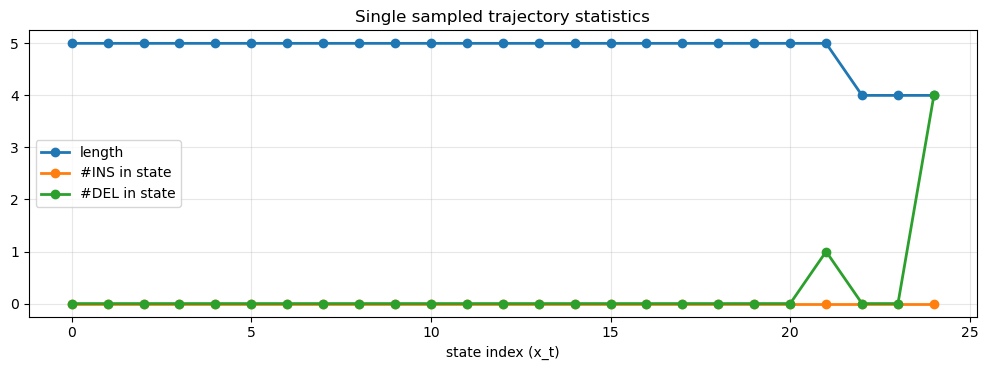

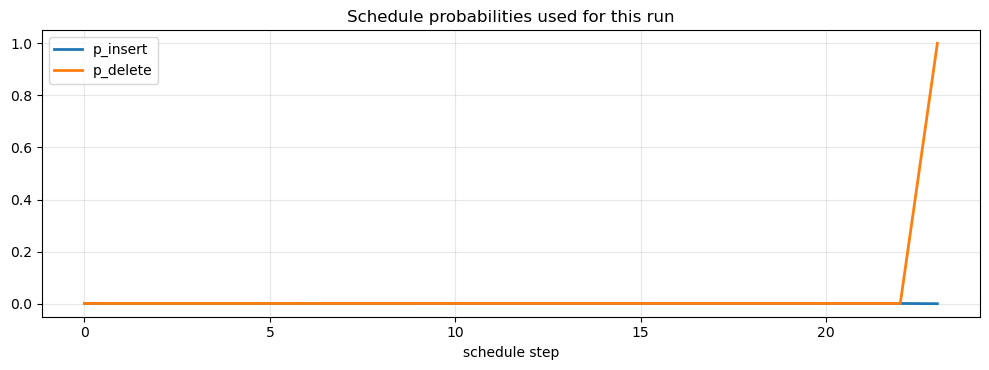

In [9]:
def state_counts(seq):
    toks = np.asarray(seq.tokens)
    L = int(np.asarray(seq.length))
    active = toks[:L]
    ins = int(np.sum(active == gfp.DynamicLengthSentinelSequence.INSERT_SENTINEL))
    dele = int(np.sum(active == gfp.DynamicLengthSentinelSequence.DELETE_SENTINEL))
    return L, ins, dele


lengths, ins_counts, del_counts = zip(*[state_counts(s) for s in states])
steps = np.arange(len(states))

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(steps, lengths, marker="o", label="length", lw=2)
ax.plot(steps, ins_counts, marker="o", label="#INS in state", lw=2)
ax.plot(steps, del_counts, marker="o", label="#DEL in state", lw=2)
ax.set_xlabel("state index (x_t)")
ax.set_title("Single sampled trajectory statistics")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(np.arange(len(p_insert)), p_insert, label="p_insert", lw=2)
ax.plot(np.arange(len(p_delete)), p_delete, label="p_delete", lw=2)
ax.set_xlabel("schedule step")
ax.set_title("Schedule probabilities used for this run")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()


## 8) GIF: Sequence trajectory + schedule pointer


saved: /Users/alfred/Documents/Code/denovo_base/notes/notebook_artifacts/small_edits_absorbing_mask_trajectory.gif


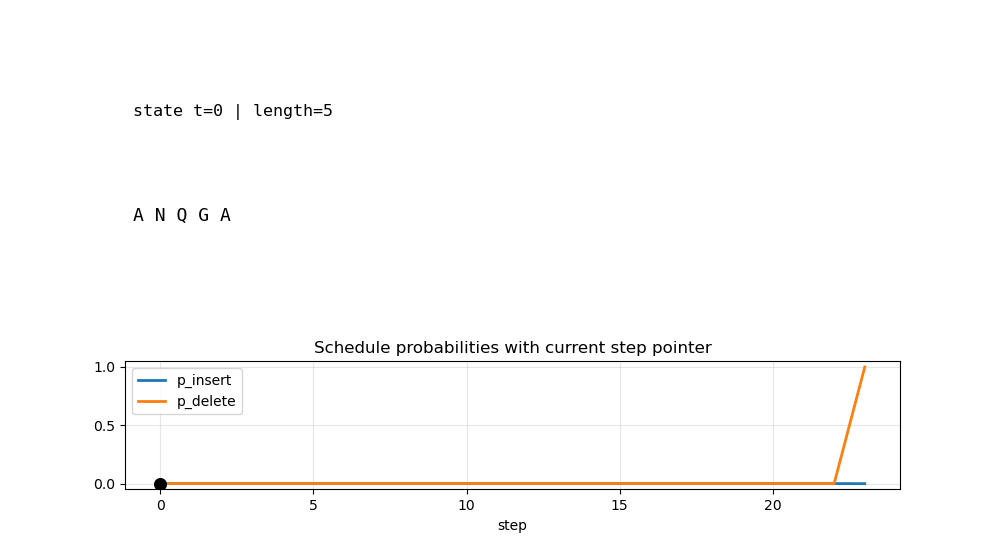

In [10]:
def make_trajectory_gif(states, p_insert, p_delete, out_path: Path):
    decoded = [" ".join(decode_dynamic_sequence(s)) for s in states]
    lengths = [int(np.asarray(s.length)) for s in states]
    n_frames = len(states)

    fig, (ax_text, ax_prob) = plt.subplots(
        2, 1, figsize=(10, 5.5), gridspec_kw={"height_ratios": [2, 1]}
    )

    ax_text.axis("off")
    title_text = ax_text.text(
        0.01,
        0.85,
        "",
        fontsize=12,
        family="monospace",
        transform=ax_text.transAxes,
        va="top",
    )
    seq_text = ax_text.text(
        0.01,
        0.45,
        "",
        fontsize=13,
        family="monospace",
        transform=ax_text.transAxes,
        va="top",
    )

    x_prob = np.arange(len(p_insert))
    ax_prob.plot(x_prob, p_insert, label="p_insert", lw=2)
    ax_prob.plot(x_prob, p_delete, label="p_delete", lw=2)
    marker = ax_prob.scatter([0], [p_insert[0]], s=70, c="black", zorder=5)
    ax_prob.set_title("Schedule probabilities with current step pointer")
    ax_prob.set_xlabel("step")
    ax_prob.grid(alpha=0.3)
    ax_prob.legend()

    def update(frame):
        step_for_prob = min(frame, len(p_insert) - 1)
        title_text.set_text(f"state t={frame} | length={lengths[frame]}")
        seq_text.set_text(decoded[frame])
        marker.set_offsets(np.array([[step_for_prob, p_insert[step_for_prob]]]))
        return title_text, seq_text, marker

    anim = FuncAnimation(fig, update, frames=n_frames, interval=650, blit=False)
    return save_gif(anim, out_path, fps=2)


traj_gif_path = gif_dir / f"{schedule_name}_trajectory.gif"
_ = make_trajectory_gif(states, p_insert, p_delete, traj_gif_path)
print("saved:", traj_gif_path)
display(Image(filename=str(traj_gif_path)))


## 9) Multi-seed summary for the same schedule


mean final length: 5.0
std final length : 0.0


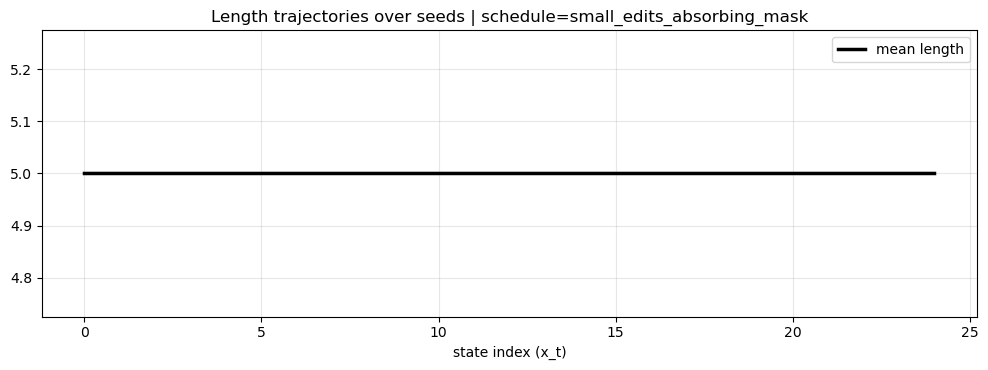

In [11]:
seeds = [0, 1, 2, 3, 4, 5]
all_lengths = []
for sd in seeds:
    st, _ = sample_forward_chain(schedule, x0_tokens=["A", "N", "Q", "G", "A"], seed=sd)
    ls = [int(np.asarray(s.length)) for s in st]
    all_lengths.append(ls)

all_lengths = np.asarray(all_lengths)

fig, ax = plt.subplots(figsize=(10, 3.8))
for i, sd in enumerate(seeds):
    ax.plot(all_lengths[i], alpha=0.35, lw=1.5)
ax.plot(all_lengths.mean(axis=0), color="black", lw=2.5, label="mean length")
ax.set_title(f"Length trajectories over seeds | schedule={schedule_name}")
ax.set_xlabel("state index (x_t)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

print("mean final length:", float(all_lengths[:, -1].mean()))
print("std final length :", float(all_lengths[:, -1].std()))


## 10) Quick preset comparison (same toy input)


In [12]:
compare_names = [
    "near_inplace_uniform",
    "small_edits_uniform",
    "small_edits_absorbing_mask",
    "medium_edits_uniform",
]
summary = []
for name in compare_names:
    sch, cfg, _ = build_schedule(name)
    mats_, dlogits_, dprobs_, _, _, pin, pdel, _ = extract_schedule_arrays(sch)
    st, _ = sample_forward_chain(sch, x0_tokens=["A", "N", "Q", "G", "A"], seed=0)
    lengths_ = np.array([int(np.asarray(s.length)) for s in st], dtype=np.int32)
    summary.append((name, float(pin.mean()), float(pdel.mean()), float(dprobs_.mean()), int(lengths_[-1])))

for row in summary:
    print(
        f"preset={row[0]:>28s} | mean p_insert={row[1]:.4f} | mean p_delete={row[2]:.4f} "
        f"| mean P(INS->token)={row[3]:.4f} | final length={row[4]}"
    )


preset=        near_inplace_uniform | mean p_insert=0.0000 | mean p_delete=0.0417 | mean P(INS->token)=0.2000 | final length=5
preset=         small_edits_uniform | mean p_insert=0.0008 | mean p_delete=0.0425 | mean P(INS->token)=0.2000 | final length=5
preset=  small_edits_absorbing_mask | mean p_insert=0.0008 | mean p_delete=0.0425 | mean P(INS->token)=0.2000 | final length=5
preset=        medium_edits_uniform | mean p_insert=0.0035 | mean p_delete=0.0451 | mean P(INS->token)=0.2000 | final length=5
